# Training pipeline
Notebook nay doc du lieu train, kiem tra phan bo nhan, tim mo hinh tot nhat bang Stratified CV, va luu mo hinh.

In [19]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import joblib

In [20]:
train_path = "data_train.csv"
df = pd.read_csv(train_path)
df.head()

,title,category
0,hành_trình công_lý gái gốc việt vũ_trụ,Thế giới
1,phụ_nữ chèo thuyền xuyên đại tây dương 61,Thế giới
2,iran cảnh_báo nga vụ khủng_bố nhà_hát,Thế giới
3,việt nam tham_gia định_hình phát_triển tương_l...,Thế giới
4,xóa_hình xăm sám_hối ramadan,Thế giới


In [21]:

text_col = "title"
label_col = "category"
X = df[text_col].astype(str)
y = df[label_col].astype(str)

print("Text column:", text_col)
print("Label column:", label_col)
print("Num rows:", len(df))
print("Label distribution:")
print(pd.Series(y).value_counts())
# số lượng từ trong tập dữ liệu
total_words = X.apply(lambda x: len(x.split())).sum()
print("Total words in dataset:", total_words)
# số lượng từ trung bình mỗi văn bản
avg_words_per_doc = X.apply(lambda x: len(x.split())).mean()
print("Average words per document:", avg_words_per_doc)

Text column: title
Label column: category
Num rows: 4776
Label distribution:
category
Thế giới     600
Giáo dục     600
Pháp luật    600
Thể thao     600
Du lịch      600
Sức khỏe     600
Đời sống     600
Giải trí     576
Name: count, dtype: int64
Total words in dataset: 32489
Average words per document: 6.802554438860971


In [22]:
# Toggle models
use_linearsvc = True
use_logreg = True
use_multinomialnb = True

# Original (baseline) grids
tfidf_param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2],
}

linearsvc_param_grid = {
    "clf__C": [0.1, 1, 10],
}

logreg_param_grid = {
    "clf__C": [0.1, 1, 10],
    "clf__solver": ["lbfgs", "saga"],
}

multinomialnb_param_grid = {
    "clf__alpha": [0.1, 0.5, 1.0],
}

In [23]:
pipelines = []

if use_linearsvc:
    pipelines.append({
        "name": "tfidf_linearsvc",
        "pipeline": Pipeline([
            ("tfidf", TfidfVectorizer()),
            ("clf", LinearSVC())
        ]),
        "params": {
            **tfidf_param_grid,
            **linearsvc_param_grid,
        }
    })

if use_logreg:
    pipelines.append({
        "name": "tfidf_logreg",
        "pipeline": Pipeline([
            ("tfidf", TfidfVectorizer()),
            ("clf", LogisticRegression(max_iter=300))
        ]),
        "params": {
            **tfidf_param_grid,
            **logreg_param_grid,
        }
    })

if use_multinomialnb:
    pipelines.append({
        "name": "tfidf_multinomialnb",
        "pipeline": Pipeline([
            ("tfidf", TfidfVectorizer()),
            ("clf", MultinomialNB())
        ]),
        "params": {
            **tfidf_param_grid,
            **multinomialnb_param_grid,
        }
    })

if not pipelines:
    raise ValueError("No models enabled. Set use_linearsvc, use_logreg, or use_multinomialnb to True.")

In [24]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

best_model = None
best_score = -1
best_name = None
best_grid = None

for item in pipelines:
    print("\nRunning:", item["name"])
    grid_search = GridSearchCV(
        estimator=item["pipeline"],
        param_grid=item["params"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True
    )
    grid_search.fit(X, y)
    print("Best score:", grid_search.best_score_)
    print("Best params:", grid_search.best_params_)
    if grid_search.best_score_ > best_score:
        best_score = grid_search.best_score_
        best_model = grid_search.best_estimator_
        best_name = item["name"]
        best_grid = grid_search

best_score, best_name


Running: tfidf_linearsvc
Best score: 0.8328387386916078
Best params: {'clf__C': 1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

Running: tfidf_logreg
Best score: 0.8278049624817687
Best params: {'clf__C': 10, 'clf__solver': 'saga', 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

Running: tfidf_multinomialnb
Best score: 0.8264143279260431
Best params: {'clf__alpha': 0.1, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}


(np.float64(0.8328387386916078), 'tfidf_linearsvc')

In [25]:
vectorizer = best_model.named_steps["tfidf"]
vocab_size = len(vectorizer.vocabulary_)
print("Train F1 (best_score_):", best_score)
print("Best model:", best_model)
print("Vocab size:", vocab_size)

Train F1 (best_score_): 0.8328387386916078
Best model: Pipeline(steps=[('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                ('clf', LinearSVC(C=1))])
Vocab size: 27870


In [26]:
model_path = "best_model.pkl"
joblib.dump(best_model, model_path)
model_path

'best_model.pkl'

Train Macro F1-score: 1.0
Confusion Matrix (train):
[[600   0   0   0   0   0   0   0]
 [  0 600   0   0   0   0   0   0]
 [  0   0 576   0   0   0   0   0]
 [  0   0   0 600   0   0   0   0]
 [  0   0   0   0 600   0   0   0]
 [  0   0   0   0   0 600   0   0]
 [  0   0   0   0   0   0 600   0]
 [  0   0   0   0   0   0   0 600]]


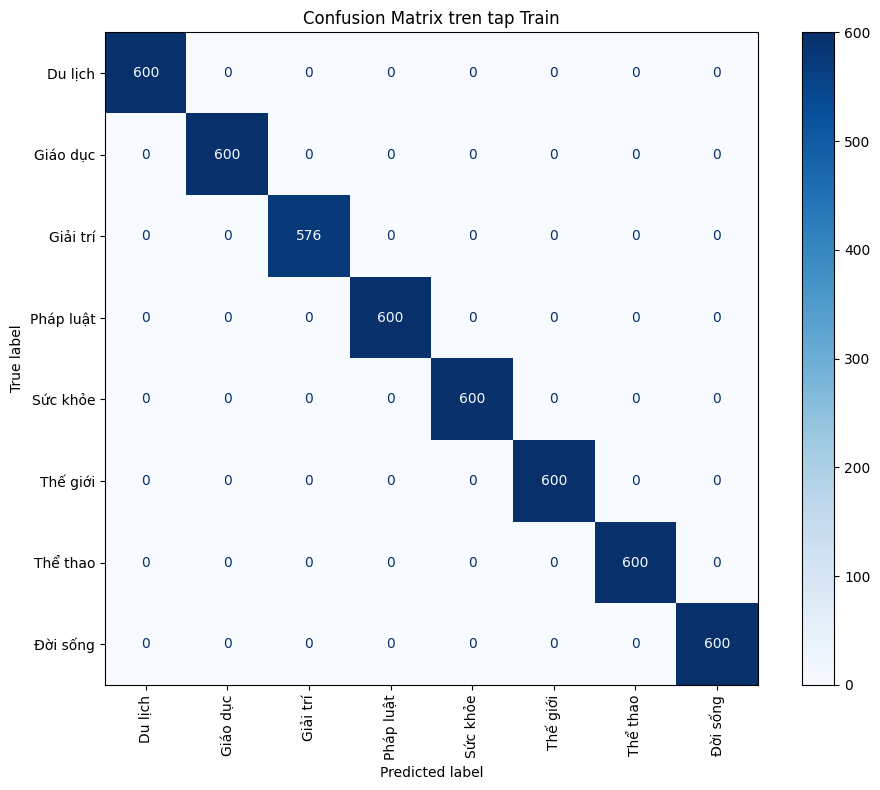

In [27]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# Evaluate on full training set
y_pred_train = best_model.predict(X)
macro_f1_train = f1_score(y, y_pred_train, average="macro")
cm_train = confusion_matrix(y, y_pred_train)

print("Train Macro F1-score:", macro_f1_train)
print("Confusion Matrix (train):")
print(cm_train)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation="vertical")
plt.title("Confusion Matrix tren tap Train")
plt.tight_layout()
plt.show()